# 06 · Thixotropy

Stir a paint and it thins; leave it and it thickens again. A drilling mud gels when circulation stops, and
the pressure to restart it grows with the time it has rested. This time dependence - **thixotropy** - comes
from a microstructure (flocs, a particle network) that shear breaks down and rest rebuilds. The stress then
depends on the shear *history*, not only on the current shear rate.

**What you will learn**
- explain thixotropy with a structural-kinetics model
- interpret hysteresis loops and know their limits
- fit structural parameters to a step test
- estimate gel strength and restart stresses after rest

**Before you start:** notebooks 03-04 and 15; exponential functions  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engrheo is missing): install it from GitHub
    import engrheo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engrheo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from engrheo import datasets, thixotropy as th
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## The structural-kinetics picture
A structure parameter $\lambda$ (1 = fully built, 0 = broken down) obeys
$d\lambda/dt = k_b(1 - \lambda) - k_d\dot\gamma\lambda$ - build-up at rest, breakdown by shear - and the stress depends on it,
$\tau = \lambda\tau_y + (\eta_\infty + \Delta\eta\,\lambda)\dot\gamma$.

## A paint: the hysteresis loop
The classic thixotropy test ramps the shear rate up and down:

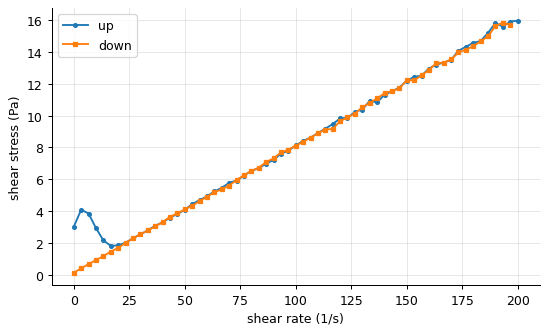

loop area 44 Pa/s


In [2]:
paint = pd.read_csv(datasets.path("paint_hysteresis_loop.csv"), comment="#")
up, down = paint[paint.direction == "up"], paint[paint.direction == "down"]
plt.plot(up.shear_rate_1_s, up.shear_stress_Pa, "o-", ms=3, label="up")
plt.plot(down.shear_rate_1_s, down.shear_stress_Pa, "s-", ms=3, label="down")
plt.xlabel("shear rate (1/s)"); plt.ylabel("shear stress (Pa)"); plt.legend(); plt.show()
x, y = paint.shear_rate_1_s.to_numpy(), paint.shear_stress_Pa.to_numpy()    # the loop, in time order
area = 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))      # shoelace formula for a closed polygon
print(f"loop area {area:.0f} Pa/s")

The downward curve lies below the upward one: during the ramp the structure was broken down faster than
it could rebuild. The loop area is a popular thixotropy index - but it is not a material property. With
the true parameters of this paint, the model shows how the area depends on how fast the test is run:

In [3]:
p_paint = th.Params(3.0, 0.08, 0.4, 0.02, 0.08)
for t_ramp in (0.05, 0.2, 1, 5, 60, 600, 6000):
    print(f"ramp time {t_ramp:>7g} s: loop area {th.hysteresis_loop(p_paint, 200.0, t_ramp)['area']:6.0f} Pa/s")

ramp time    0.05 s: loop area   2391 Pa/s
ramp time     0.2 s: loop area   3520 Pa/s


ramp time       1 s: loop area   1184 Pa/s


ramp time       5 s: loop area    283 Pa/s


ramp time      60 s: loop area     40 Pa/s


ramp time     600 s: loop area      9 Pa/s


ramp time    6000 s: loop area      2 Pa/s


The area peaks for ramps of a fraction of a second and falls on both sides: very fast ramps leave no time
for breakdown, very slow ramps keep the structure near equilibrium. Over the ramp times used in practice
the area changes by orders of magnitude - loop areas can only be compared between tests run in exactly
the same way. Step tests, below, separate the time scales properly.

## Cement paste: a step test and the structural parameters

steps 10 -> 100 -> 10 1/s only (first 600 s):
   tau_y = 41.8 (+/-182%), eta_inf = 0.1 (+/-1%), d_eta = 2.59 (+/-182%), k_build = 0.00583 (+/-182%), k_break = 0.0202 (+/-6%)
full protocol incl. rest and 1 1/s probe:
   tau_y = 25 (+/-0%), eta_inf = 0.1 (+/-0%), d_eta = 1.5 (+/-1%), k_build = 0.00997 (+/-0%), k_break = 0.02 (+/-0%)
true: tau_y = 25, eta_inf = 0.1, d_eta = 1.5, k_build = 0.01, k_break = 0.02


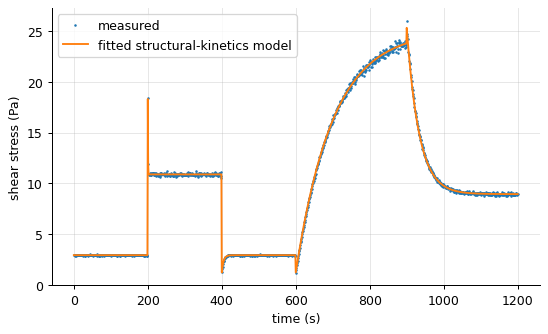

In [4]:
cem = pd.read_csv(datasets.path("cement_paste_step_test.csv"), comment="#")
t, rate, tau = cem.time_s.to_numpy(), cem.shear_rate_1_s.to_numpy(), cem.shear_stress_Pa.to_numpy()
names = ["tau_y", "eta_inf", "d_eta", "k_build", "k_break"]

def model(p, n):
    prm = th.Params(*p)
    return th.simulate(prm, t[:n], rate[:n], lam0=th.equilibrium_structure(prm, rate[0]))["stress"]

def fit_first(n):
    use = rate[:n] > 0                                  # at rest the stress is zero: nothing to fit
    f = optimize.least_squares(lambda p: np.log(model(p, n)[use] / tau[:n][use]), [10, 0.5, 1, 0.05, 0.05],
                               bounds=(1e-6, np.inf), x_scale="jac")
    cov = np.linalg.inv(f.jac.T @ f.jac) * np.sum(f.fun**2) / (use.sum() - 5)
    return f.x, np.sqrt(np.diag(cov)) / f.x

for label, n in (("steps 10 -> 100 -> 10 1/s only (first 600 s)", 600), ("full protocol incl. rest and 1 1/s probe", t.size)):
    p, rel = fit_first(n)
    print(label + ":\n   " + ", ".join(f"{n_} = {v:.3g} (+/-{r:.0%})" for n_, v, r in zip(names, p, rel)))
print("true: tau_y = 25, eta_inf = 0.1, d_eta = 1.5, k_build = 0.01, k_break = 0.02")
p_fit, _ = fit_first(t.size)
plt.plot(t, tau, ".", ms=2, label="measured"); plt.plot(t, model(p_fit, t.size), label="fitted structural-kinetics model")
plt.xlabel("time (s)"); plt.ylabel("shear stress (Pa)"); plt.legend(); plt.show()

After the step up the stress jumps and then decays as the structure breaks down; after the step back it
drops below equilibrium and slowly recovers. Fitted to these steps alone, the model reproduces the data -
yet its parameters are uncertain by more than 100 %: scaling the structural stresses and the rate constants
together yields almost the same stress history. The rest period breaks that ambiguity: the jump in stress
when shearing resumes at 1 1/s measures how much structure was rebuilt, and with it the build-up rate.
With the full protocol all five parameters are determined to about 1 %. **Design thixotropy tests with
rest periods** - a lesson similar to the creep-recovery test of notebook 07.

## Gel strength after rest
Drilling engineers measure "gel strengths" - the stress needed to start flow after 10 s and 10 min of rest.
With the fitted model the structure recovers as $\lambda(t) = 1 - (1 - \lambda_0)e^{-k_b t}$:

In [5]:
prm = th.Params(*p_fit)
lam0 = th.equilibrium_structure(prm, 100.0)                     # after circulating at 100 1/s
for rest in (10, 600, 3600):
    lam = 1 - (1 - lam0) * np.exp(-prm.k_build * rest)
    print(f"after {rest:5d} s of rest: structure {lam:.2f}, stress to restart flow {lam * prm.tau_y:5.1f} Pa")

after    10 s of rest: structure 0.10, stress to restart flow   2.5 Pa
after   600 s of rest: structure 1.00, stress to restart flow  24.9 Pa
after  3600 s of rest: structure 1.00, stress to restart flow  25.0 Pa


The restart stress grows with rest time - and with it the pump pressure needed to restart a pipeline
(notebook 15: $\Delta P_{start} = 4\tau_y L/D$). For cement paste this recovery also underlies the loss of
workability at rest; real cement adds irreversible hydration on top.

## Inside the algorithm: the exact step response
At a constant shear rate the structure equation is linear, and its solution relaxes exponentially to
$\lambda_{eq} = k_b/(k_b + k_d\dot\gamma)$ with rate constant $k_b + k_d\dot\gamma$. For the step from 10 to 100 1/s:

In [6]:
k = prm.k_build + prm.k_break * 100.0
lam_eq, lam_start = prm.k_build / k, th.equilibrium_structure(prm, 10.0)
ts = np.array([200.0, 250.0, 300.0])
by_hand = lam_eq + (lam_start - lam_eq) * np.exp(-k * (ts - 200))
lib = th.simulate(prm, t, rate, lam0=lam_start)["structure"][[200, 250, 300]]      # rows at t = 200, 250, 300 s
print("by hand:", np.round(by_hand, 6), " library:", np.round(lib, 6))

by hand: [0.047543 0.004967 0.004967]  library: [0.047543 0.004967 0.004967]


## Exercises
1. A cement grout line (50 mm, 200 m) stops for 10 min, and for 1 h. Using the fitted cement-paste model and $\Delta P = 4\tau_{restart}L/D$, estimate the pressure needed to restart flow in each case.
2. For the paint, find the ramp time that gives the largest loop area. Relate it to the build-up and breakdown time scales $1/k_b$ and $1/(k_d\dot\gamma)$.
3. **Implement it yourself:** integrate the structure equation for the step test with the explicit Euler method (time step 1 s, then 10 s) and compare with the exact interval solution of `th.simulate`. When does Euler fail?